In [ ]:
import csv
import random
import torch
import torch.utils.data
import numpy as np
import pandas as pd

### Data Cleaning

In [ ]:
header = ['age', 'work', 'fnlwgt', 'edu', 'yredu', 'marriage', 'occupation', 'relationship', 'race', 'sex', 'capgain', 'caploss', 'workhr', 'country']

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    names=header,
    index_col=False)

/var/folders/ht/879gb0f17j9__nx8w63714yw0000gn/T/ipykernel_63332/1831985018.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(


In [ ]:
df.shape 

(32561, 14)

#### Continuous Features

In [ ]:
continuous_cols = ["age", "yredu", "capgain", "caploss", "workhr"]

for col in continuous_cols:
    print(f"For {col}: Min value: {df[col].min()}. Max value: {df[col].max()}. Avg value: {df[col].mean()}")
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min()) # Min-Max norm
    
df[continuous_cols].head(3)

For age: Min value: 17. Max value: 90. Avg value: 38.58164675532078
For yredu: Min value: 1. Max value: 16. Avg value: 10.0806793403151
For capgain: Min value: 0. Max value: 99999. Avg value: 1077.6488437087312
For caploss: Min value: 0. Max value: 4356. Avg value: 87.303829734959
For workhr: Min value: 1. Max value: 99. Avg value: 40.437455852092995


,age,yredu,capgain,caploss,workhr
0,0.301370,0.800000,0.02174,0.0,0.397959
1,0.452055,0.800000,0.00000,0.0,0.122449
2,0.287671,0.533333,0.00000,0.0,0.397959


#### Categorical Features

In [22]:
df

,age,work,fnlwgt,edu,yredu,marriage,occupation,relationship,race,sex,capgain,caploss,workhr,country
0,0.301370,State-gov,77516,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.021740,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,83311,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,215646,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,234721,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,338409,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.136986,Private,257302,Assoc-acdm,0.733333,Married-civ-spouse,Tech-support,Wife,White,Female,0.000000,0.0,0.377551,United-States
32557,0.315068,Private,154374,HS-grad,0.533333,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.000000,0.0,0.397959,United-States
32558,0.561644,Private,151910,HS-grad,0.533333,Widowed,Adm-clerical,Unmarried,White,Female,0.000000,0.0,0.397959,United-States
32559,0.068493,Private,201490,HS-grad,0.533333,Never-married,Adm-clerical,Own-child,White,Male,0.000000,0.0,0.193878,United-States


In [ ]:
(sum(df["sex"] == " Female") / df['sex'].count())*100

np.float64(33.07945087681583)

In [ ]:
contcols = ["age", "yredu", "capgain", "caploss", "workhr"]
catcols = ["work", "marriage", "occupation", "edu", "relationship", "sex"]

features = contcols + catcols

df = df[features]

In [26]:
missing = pd.concat([df[c] == " ?" for c in catcols], axis=1).any(axis=1)
df_with_missing = df[missing]
df_not_missing = df[~missing]

In [31]:
num_missing = len(df_with_missing)
num_not_missing = len(df_not_missing)
total = num_missing + num_not_missing
percent_removed = (num_missing / total) * 100

print(f"Records with missing features: {num_missing}")
print(f"Percentage of records removed: {percent_removed:.2f}%")

Records with missing features: 1843
Percentage of records removed: 5.66%


#### One-Hot Encoding

In [30]:
print(set(df_not_missing['work']))

{' Federal-gov', ' Self-emp-not-inc', ' Local-gov', ' Private', ' State-gov', ' Self-emp-inc', ' Without-pay'}


In [32]:
data = pd.get_dummies(df_not_missing)

In [33]:
data[:3]

,age,yredu,capgain,caploss,workhr,work_ Federal-gov,work_ Local-gov,work_ Private,work_ Self-emp-inc,work_ Self-emp-not-inc,...,edu_ Prof-school,edu_ Some-college,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,sex_ Female,sex_ Male
0,0.301370,0.800000,0.02174,0.0,0.397959,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,0.452055,0.800000,0.00000,0.0,0.122449,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
2,0.287671,0.533333,0.00000,0.0,0.397959,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [35]:
print(f"# Features: {data.shape[1]}")

# Features: 57


5 continuous features (kept as is was).

52 binary columns created from the 6 categorical features

#### One-Hot Conversion

In [36]:
datanp = data.values.astype(np.float32)

In [ ]:
cat_index = {}  # Mapping of feature. start index of feature in a record
cat_values = {} # Mapping of feature -> list of categorical values the feature can take

for i, header in enumerate(data.keys()):
    if "_" in header: # categorical header
        feature, value = header.split()
        feature = feature[:-1] 
        if feature not in cat_index:
            cat_index[feature] = i
            cat_values[feature] = [value]
        else:
            cat_values[feature].append(value)

def get_onehot(record, feature):
    """
    Return the portion of `record` that is the one-hot encoding
    of `feature`. For example, since the feature "work" is stored
    in the indices [5:12] in each record, calling `get_range(record, "work")`
    is equivalent to accessing `record[5:12]`.
    
    Args:
        - record: a numpy array representing one record, formatted
                  the same way as a row in `data.np`
        - feature: a string, should be an element of `catcols`
    """
    start_index = cat_index[feature]
    stop_index = cat_index[feature] + len(cat_values[feature])
    return record[start_index:stop_index]

def get_categorical_value(onehot, feature):
    index = np.argmax(onehot)
    return cat_values[feature][index]

In [ ]:
def get_feature(record, feature):
    """
    Return the categorical feature value of a record
    """
    onehot = get_onehot(record, feature)
    return get_categorical_value(onehot, feature)

def get_features(record):
    """
    Return a dictionary of all categorical feature values of a record
    """
    return { f: get_feature(record, f) for f in catcols }

#### Train/Test Split

In [ ]:
np.random.seed(50)

indices = np.arange(len(datanp))
np.random.shuffle(indices)

# Split points
train_split = int(0.7 * len(datanp))
val_split = int(0.85 * len(datanp)) 

# Slice indices
train_indices = indices[:train_split]
val_indices = indices[train_split:val_split]
test_indices = indices[val_split:]

# Create the datasets
train_data = datanp[train_indices]
val_data = datanp[val_indices]
test_data = datanp[test_indices]

print(f"# of items in Training set: {len(train_data)}")
print(f"# of items in Validation set: {len(val_data)}")
print(f"# of items in Test set: {len(test_data)}")

# of items in Training set: 21502
# of items in Validation set: 4608
# of items in Test set: 4608


### Model Setup

In [ ]:
from torch import nn

class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(57, 57),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(57, 57), 
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Since our target data is entirely within the [0,1] interval the model's output layer must be restricted to that same range to make the reconstruction mathematically possible and the MSE loss calculation meaningful.

## Training

In [ ]:
import matplotlib.pyplot as plt

def zero_out_feature(records, feature):
    """ Set the feature missing in records, by setting the appropriate
    columns of records to 0
    """
    start_index = cat_index[feature]
    stop_index = cat_index[feature] + len(cat_values[feature])
    records[:, start_index:stop_index] = 0
    return records

def zero_out_random_feature(records):
    """ Set one random feature missing in records, by setting the 
    appropriate columns of records to 0
    """
    return zero_out_feature(records, random.choice(catcols))

def train(model, train_loader, valid_loader, num_epochs=30, learning_rate=0.0001):
    torch.manual_seed(42)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    iters, losses, train_acc, val_acc = [], [], [], []

    n = 0
    for epoch in range(num_epochs):
        for data in train_loader:
            model.train() 
            
            # Forward pass
            datam = zero_out_random_feature(data.clone()) # zero out one categorical feature
            recon = model(datam)
            loss = criterion(recon, data)
            
            #Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Track metrics every 100 iterations 
            if n % 100 == 0:
                iters.append(n)
                losses.append(float(loss))
                
                model.eval() 
                train_acc.append(get_accuracy(model, train_loader))
                val_acc.append(get_accuracy(model, valid_loader))
                print(f"Iter {n}; Loss {loss:.4f}; Train Acc {train_acc[-1]:.4f}; Val Acc {val_acc[-1]:.4f}")
            
            n += 1 

    # Plotting
    plt.title("Training Curve")
    plt.plot(iters, losses, label="Train Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Accuracy Curve")
    plt.plot(iters, train_acc, label="Train")
    plt.plot(iters, val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

In [45]:
def get_accuracy(model, data_loader):
    """Return the "accuracy" of the autoencoder model across a data set.
    That is, for each record and for each categorical feature, 
    we determine whether the model can successfully predict the value
    of the categorical feature given all the other features of the 
    record. The returned "accuracy" measure is the percentage of times 
    that our model is successful.
        
    Args:
       - model: the autoencoder model, an instance of nn.Module
       - data_loader: an instance of torch.utils.data.DataLoader

    Example (to illustrate how get_accuracy is intended to be called.
             Depending on your variable naming this code might require
             modification.)

        >>> model = AutoEncoder()
        >>> vdl = torch.utils.data.DataLoader(data_valid, batch_size=256, shuffle=True)
        >>> get_accuracy(model, vdl)
    """
    total = 0
    acc = 0
    for col in catcols:
        for item in data_loader: # minibatches
            inp = item.detach().numpy()
            out = model(zero_out_feature(item.clone(), col)).detach().numpy()
            for i in range(out.shape[0]): # record in minibatch
                acc += int(get_feature(out[i], col) == get_feature(inp[i], col))
                total += 1
    return acc / total

Iter 0; Loss 0.2410; Train Acc 0.2283; Val Acc 0.2316
Iter 100; Loss 0.2245; Train Acc 0.2956; Val Acc 0.2974
Iter 200; Loss 0.1984; Train Acc 0.3653; Val Acc 0.3645
Iter 300; Loss 0.1588; Train Acc 0.4007; Val Acc 0.4002
Iter 400; Loss 0.1214; Train Acc 0.4039; Val Acc 0.4030
Iter 500; Loss 0.0983; Train Acc 0.4137; Val Acc 0.4132
Iter 600; Loss 0.0840; Train Acc 0.4560; Val Acc 0.4538
Iter 700; Loss 0.0758; Train Acc 0.4570; Val Acc 0.4549
Iter 800; Loss 0.0739; Train Acc 0.4604; Val Acc 0.4580
Iter 900; Loss 0.0711; Train Acc 0.4636; Val Acc 0.4616
Iter 1000; Loss 0.0682; Train Acc 0.4699; Val Acc 0.4679
Iter 1100; Loss 0.0680; Train Acc 0.4803; Val Acc 0.4782
Iter 1200; Loss 0.0634; Train Acc 0.4967; Val Acc 0.4939
Iter 1300; Loss 0.0584; Train Acc 0.5055; Val Acc 0.5051
Iter 1400; Loss 0.0575; Train Acc 0.5144; Val Acc 0.5136
Iter 1500; Loss 0.0603; Train Acc 0.5215; Val Acc 0.5206
Iter 1600; Loss 0.0560; Train Acc 0.5296; Val Acc 0.5289
Iter 1700; Loss 0.0554; Train Acc 0.5389; V

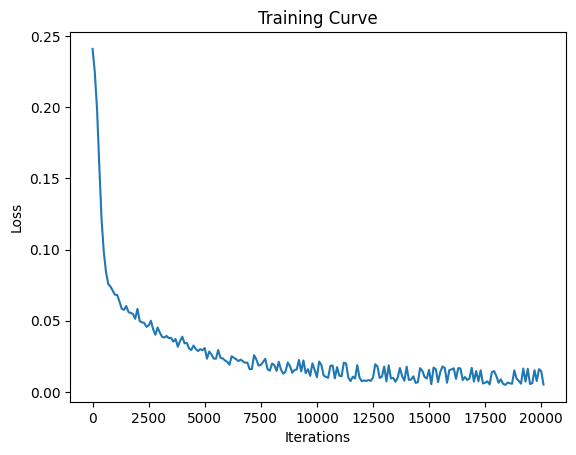

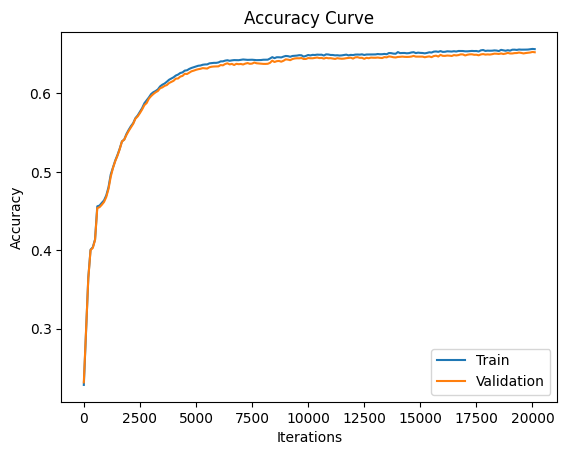

In [49]:
from torch.utils.data import DataLoader

train_tensor = torch.from_numpy(train_data)
val_tensor = torch.from_numpy(val_data)
test_tensor = torch.from_numpy(test_data)

train_loader = DataLoader(train_tensor, batch_size=64, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=64, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=64, shuffle=False)

mdl = AutoEncoder()
train(mdl, train_loader, val_loader, num_epochs=60, learning_rate=0.0001) #num epochs changed after tuning

### Testing

In [50]:
mdl.eval()
test_acc = get_accuracy(mdl, test_loader)
print(test_acc)

0.6518012152777778


### Heuristic as a Baseline

In [52]:
def get_baseline_accuracy(train_df, test_df, categorical_cols):
    total_matches = 0
    total_predictions = 0
    
    for col in categorical_cols:
        most_common_value = train_df[col].mode()[0]
        matches = (test_df[col] == most_common_value).sum()
        total_matches += matches
        total_predictions += len(test_df)
        
        print(f"Feature: {col}. Most Common: {most_common_value}. Accuracy: {matches/len(test_df)}")

    return total_matches / total_predictions

train_df = df_not_missing.iloc[train_indices]
test_df = df_not_missing.iloc[test_indices]
baseline_acc = get_baseline_accuracy(train_df, test_df, catcols)

print(f"Overall Baseline Test Accuracy: {baseline_acc * 100}%")

Feature: work. Most Common:  Private. Accuracy: 0.7426215277777778
Feature: marriage. Most Common:  Married-civ-spouse. Accuracy: 0.4622395833333333
Feature: occupation. Most Common:  Prof-specialty. Accuracy: 0.13151041666666666
Feature: edu. Most Common:  HS-grad. Accuracy: 0.3237847222222222
Feature: relationship. Most Common:  Husband. Accuracy: 0.4105902777777778
Feature: sex. Most Common:  Male. Accuracy: 0.6703559027777778
Overall Baseline Test Accuracy: 45.68504050925926%


My test accuracy of approximately 65.18% is higher than the baseline accuracy of 45.69%, representing an improvement of 20%. While the baseline model relies on simply guessing the most frequent category for every missing value, my autoencoder’s superior performance proves it has successfully learned the underlying correlations between features. 

In [53]:
first_person = test_df.iloc[0]
print(first_person)

age                    0.657534
yredu                       0.8
capgain                0.067231
caploss                     0.0
workhr                 0.397959
work                    Private
marriage               Divorced
occupation       Prof-specialty
edu                   Bachelors
relationship      Not-in-family
sex                        Male
Name: 30728, dtype: object


Pretty reasonable for a human to guess the education level. The yredu value can identify the person's highest degree. And also, the occupation "Prof-specialty" strongly correlates with having completed a university level education.

In [55]:
first_record = test_tensor[0].unsqueeze(0)
input_record = zero_out_feature(first_record.clone(),"edu")

mdl.eval()

with torch.no_grad():
    reconstruction = mdl(input_record)
    
predicted_edu = get_feature(reconstruction[0].numpy(),"edu")
actual_edu = get_feature(test_tensor[0].numpy(),"edu")

print(f"Model's Predicted Education: {predicted_edu}")
print(f"Actual Education: {actual_edu}")

Model's Predicted Education: Bachelors
Actual Education: Bachelors


In [56]:
baseline_prediction_edu = train_df['edu'].mode()[0]
print(f"Baseline Model Prediction for Education: {baseline_prediction_edu}")

Baseline Model Prediction for Education:  HS-grad
